In [54]:
# Import libraries
import pandas as pd
import numpy as np
import seaborn as sns   # for outlier detection
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split

In [55]:
# Read the dataset directly
df = pd.read_csv('Churn_Modelling.csv')
print("First 5 rows of the dataset:")
df.head()

First 5 rows of the dataset:


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [56]:
# Find missing values
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [57]:
# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns
print("\nCategorical columns:", categorical_cols.tolist())


Categorical columns: ['Surname', 'Geography', 'Gender']


In [58]:
# Apply Label Encoding to categorical columns
label_encoder = LabelEncoder()
for col in categorical_cols:
    df[col] = label_encoder.fit_transform(df[col])

print("\nData after encoding:")
df.head(10)


Data after encoding:


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,1115,619,0,0,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,1177,608,2,0,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,2040,502,0,0,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,289,699,0,0,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,1822,850,2,0,43,2,125510.82,1,1,1,79084.10,0
5,6,15574012,537,645,2,1,44,8,113755.78,2,1,0,149756.71,1
6,7,15592531,177,822,0,1,50,7,0.00,2,1,1,10062.80,0
7,8,15656148,2000,376,1,0,29,4,115046.74,4,1,0,119346.88,1
8,9,15792365,1146,501,0,1,44,4,142051.07,2,0,1,74940.50,0
9,10,15592389,1081,684,0,1,27,2,134603.88,1,1,1,71725.73,0


In [ ]:
#Handling missing values only for numeric columns
for col in df.select_dtypes(include=['float64', 'int64']).columns:
    df[col].fillna(df[col].mean().round(1), inplace=True)

C:\Users\admin\AppData\Local\Temp\ipykernel_20688\1127166731.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean().round(1), inplace=True)


In [60]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


Detecting outliers (example: CreditScore column):


<Axes: xlabel='CreditScore'>

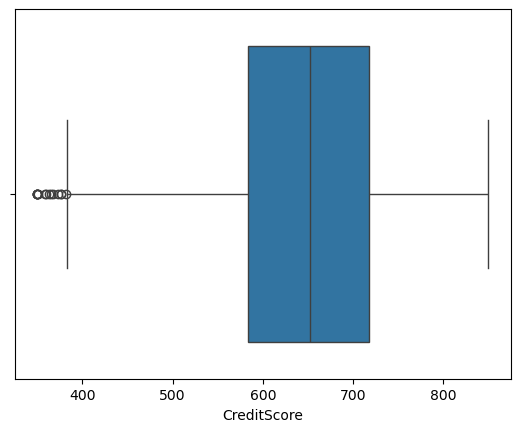

In [61]:
#Detect Outliers (example using seaborn)
print("\nDetecting outliers (example: CreditScore column):")
sns.boxplot(x=df['CreditScore'])

In [ ]:
#Example statistics for 'CreditScore'
print("\nStatistics for 'CreditScore':")
df['CreditScore'].describe()


Statistics for 'CreditScore':


count    10000.000000
mean       650.528800
std         96.653299
min        350.000000
25%        584.000000
50%        652.000000
75%        718.000000
max        850.000000
Name: CreditScore, dtype: float64

In [63]:
#Splitting features (X) and labels (y)
X = df.drop('Exited', axis=1).values  # Features (drop target column)
y = df['Exited'].values   

print("\nFeature Matrix (X):")
print(X)
print("\nLabel Vector (y):")
print(y)


Feature Matrix (X):
[[1.0000000e+00 1.5634602e+07 1.1150000e+03 ... 1.0000000e+00
  1.0000000e+00 1.0134888e+05]
 [2.0000000e+00 1.5647311e+07 1.1770000e+03 ... 0.0000000e+00
  1.0000000e+00 1.1254258e+05]
 [3.0000000e+00 1.5619304e+07 2.0400000e+03 ... 1.0000000e+00
  0.0000000e+00 1.1393157e+05]
 ...
 [9.9980000e+03 1.5584532e+07 1.5700000e+03 ... 0.0000000e+00
  1.0000000e+00 4.2085580e+04]
 [9.9990000e+03 1.5682355e+07 2.3450000e+03 ... 1.0000000e+00
  0.0000000e+00 9.2888520e+04]
 [1.0000000e+04 1.5628319e+07 2.7510000e+03 ... 1.0000000e+00
  0.0000000e+00 3.8190780e+04]]

Label Vector (y):
[1 0 1 ... 1 1 0]


In [64]:
#Normalizing the features
scaler = MinMaxScaler()
X_normalized = scaler.fit_transform(X)

In [65]:
#First 5 rows after normalization
pd.DataFrame(X_normalized, columns=df.columns[:-1]).head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,0.0000,0.275616,0.380416,0.538,0.0,0.0,0.324324,0.2,0.000000,0.000000,1.0,1.0,0.506735
1,0.0001,0.326454,0.401569,0.516,1.0,0.0,0.310811,0.1,0.334031,0.000000,0.0,1.0,0.562709
2,0.0002,0.214421,0.696008,0.304,0.0,0.0,0.324324,0.8,0.636357,0.666667,1.0,0.0,0.569654
3,0.0003,0.542636,0.098601,0.698,0.0,0.0,0.283784,0.1,0.000000,0.333333,0.0,0.0,0.469120
4,0.0004,0.688778,0.621631,1.000,1.0,0.0,0.337838,0.2,0.500246,0.000000,1.0,1.0,0.395400


In [66]:
#Splitting into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(
    X_normalized, y, test_size=0.2, random_state=42
)

print("\nShapes of Training and Testing sets:")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)


Shapes of Training and Testing sets:
X_train: (8000, 13)
X_test: (2000, 13)
y_train: (8000,)
y_test: (2000,)
